<a href="https://colab.research.google.com/github/ajimotirofiat2-lgtm/AVCAD-ASSIGNMENT/blob/main/Excercise_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [9]:
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')
display(df.head())

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [38]:
print('--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---')

# Drop rows with NaN values in 'temp_ann' before separating presence/absence
df_cleaned_temp = df.dropna(subset=['temp_ann', 'Salmo trutta fario'])

# Separate data for presence and absence of Salmo trutta fario
presence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann']
absence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites count: {len(presence_temp)}")
print(f"Absence sites count: {len(absence_temp)}")

# --- Non-standardized values ---
print("\n--- Non-standardized values ---")

# Independent two-sample t-test
t_stat, p_value_ttest = stats.ttest_ind(presence_temp, absence_temp, equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-test (non-standardized): t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Mann-Whitney U test
u_stat, p_value_mw = stats.mannwhitneyu(presence_temp, absence_temp)
print(f"Mann-Whitney U test (non-standardized): U-statistic = {u_stat:.4f}, p-value = {p_value_mw:.4f}")

# --- Standardized values ---
print("\n--- Standardized values ---")

# Standardize the 'Mean Annual Temperature' column
scaler = StandardScaler()
df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])

presence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann_Standardized']
absence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann_Standardized']

# Independent two-sample t-test with standardized values
t_stat_std, p_value_ttest_std = stats.ttest_ind(presence_temp_std, absence_temp_std, equal_var=False)
print(f"T-test (standardized): t-statistic = {t_stat_std:.4f}, p-value = {p_value_ttest_std:.4f}")

# Mann-Whitney U test with standardized values
u_stat_std, p_value_mw_std = stats.mannwhitneyu(presence_temp_std, absence_temp_std)
print(f"Mann-Whitney U test (standardized): U-statistic = {u_stat_std:.4f}, p-value = {p_value_mw_std:.4f}")

print("\nComparison of results:\nStandardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.")

--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---
Presence sites count: 2941
Absence sites count: 1900

--- Non-standardized values ---
T-test (non-standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (non-standardized): U-statistic = 1027812.5000, p-value = 0.0000

--- Standardized values ---
T-test (standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (standardized): U-statistic = 1027812.5000, p-value = 0.0000

Comparison of results:
Standardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.


/tmp/ipykernel_3336/1677528662.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])


In [39]:
print('\n--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---')

# Create a contingency table
contingency_table = pd.crosstab(df['Country'], df['Salmo trutta fario'])
display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared test for independence:")
print(f"Chi-squared statistic = {chi2:.4f}")
print(f"P-value = {p_value_chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)


--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---


Salmo trutta fario,0,1
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648



Chi-squared test for independence:
Chi-squared statistic = 496.3724
P-value = 0.0000
Degrees of freedom = 3
Expected frequencies:
 [[  28.39193774   43.60806226]
 [  72.95150669  112.04849331]
 [ 341.88625025  525.11374975]
 [1532.77030533 2354.22969467]]


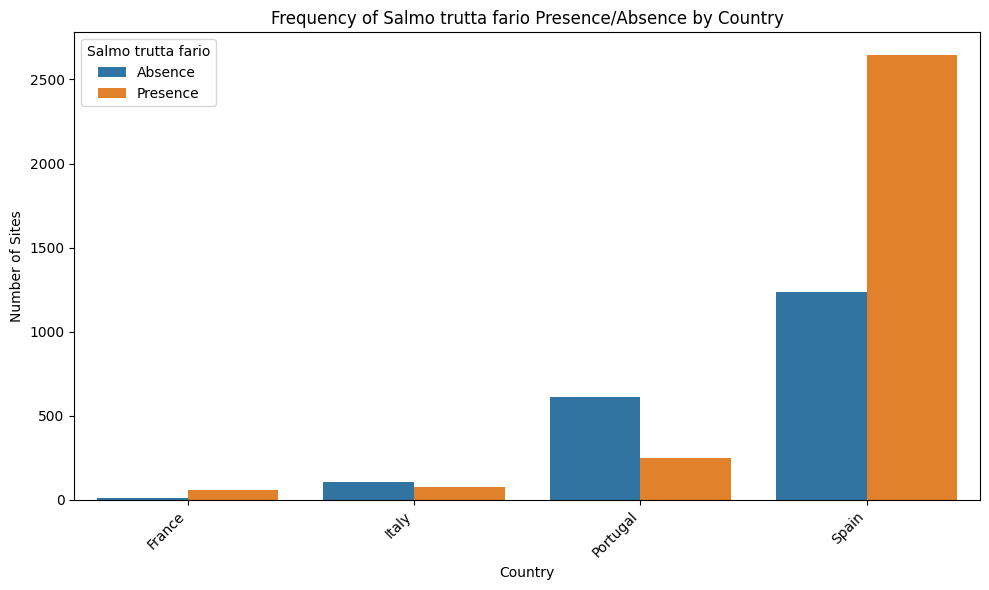

In [40]:
# For alluvial plots, a dedicated library like 'pyalluvial' or 'matplotlib' with manual drawing is often used.
# Since 'pyalluvial' is not pre-installed and can be complex for a simple visualization,
# I'll demonstrate a grouped bar chart to show the distribution, which is a common alternative
# to visualize contingency table data and provides similar insights regarding independence.

# Reshape the contingency table for plotting
plot_data = contingency_table.stack().reset_index(name='count')
plot_data.rename(columns={'Salmo trutta fario': 'Presence_Absence'}, inplace=True)
plot_data['Presence_Absence'] = plot_data['Presence_Absence'].map({0: 'Absence', 1: 'Presence'})

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='count', hue='Presence_Absence', data=plot_data)
plt.title('Frequency of Salmo trutta fario Presence/Absence by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sites')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salmo trutta fario')
plt.tight_layout()
plt.show()

In [41]:
print('\n--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---')

# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index
print("Top 8 most sampled catchments: ", top_8_catchments.tolist())

# Filter the DataFrame for these catchments and drop rows with NaN values in 'Elevation_mean_catch'
df_top_catchments = df[df['Catchment_name'].isin(top_8_catchments)].dropna(subset=['Elevation_mean_catch'])

# Create a list of 'Elevation_mean_catch' for each of the top 8 catchments
groups = [df_top_catchments[df_top_catchments['Catchment_name'] == cat]['Elevation_mean_catch'] for cat in top_8_catchments]

# Perform one-way ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA for Elevation_mean_catch among top 8 catchments:")
print(f"F-statistic = {f_stat_anova:.4f}")
print(f"P-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.")


--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---
Top 8 most sampled catchments:  ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']

One-way ANOVA for Elevation_mean_catch among top 8 catchments:
F-statistic = 227.9540
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.


In [42]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_top_catchments['Elevation_mean_catch'],
                                 groups=df_top_catchments['Catchment_name'],
                                 alpha=0.05)

print(tukey_result)

print("\nInterpretation:\nPairs with 'reject=True' show significant differences in mean elevation between those two catchments at alpha = 0.05.")

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

In [43]:
print('\n--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---')

# Perform Kruskal-Wallis H-test (non-parametric equivalent of ANOVA)
h_stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruswal-Wallis H-test for Elevation_mean_catch among top 8 catchments:")
print(f"H-statistic = {h_stat_kw:.4f}")
print(f"P-value = {p_value_kw:.4f}")

if p_value_kw < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.")

print("\nComparison with ANOVA:\nBoth ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.")


--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---
Kruswal-Wallis H-test for Elevation_mean_catch among top 8 catchments:
H-statistic = 1335.3733
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.

Comparison with ANOVA:
Both ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.


In [32]:
print('--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---')

# Drop rows with NaN values in 'temp_ann' before separating presence/absence
df_cleaned_temp = df.dropna(subset=['temp_ann', 'Salmo trutta fario'])

# Separate data for presence and absence of Salmo trutta fario
presence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann']
absence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites count: {len(presence_temp)}")
print(f"Absence sites count: {len(absence_temp)}")

# --- Non-standardized values ---
print("\n--- Non-standardized values ---")

# Independent two-sample t-test
t_stat, p_value_ttest = stats.ttest_ind(presence_temp, absence_temp, equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-test (non-standardized): t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Mann-Whitney U test
u_stat, p_value_mw = stats.mannwhitneyu(presence_temp, absence_temp)
print(f"Mann-Whitney U test (non-standardized): U-statistic = {u_stat:.4f}, p-value = {p_value_mw:.4f}")

# --- Standardized values ---
print("\n--- Standardized values ---")

# Standardize the 'Mean Annual Temperature' column
scaler = StandardScaler()
df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])

presence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann_Standardized']
absence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann_Standardized']

# Independent two-sample t-test with standardized values
t_stat_std, p_value_ttest_std = stats.ttest_ind(presence_temp_std, absence_temp_std, equal_var=False)
print(f"T-test (standardized): t-statistic = {t_stat_std:.4f}, p-value = {p_value_ttest_std:.4f}")

# Mann-Whitney U test with standardized values
u_stat_std, p_value_mw_std = stats.mannwhitneyu(presence_temp_std, absence_temp_std)
print(f"Mann-Whitney U test (standardized): U-statistic = {u_stat_std:.4f}, p-value = {p_value_mw_std:.4f}")

print("\nComparison of results:\nStandardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.")

--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---
Presence sites count: 2941
Absence sites count: 1900

--- Non-standardized values ---
T-test (non-standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (non-standardized): U-statistic = 1027812.5000, p-value = 0.0000

--- Standardized values ---
T-test (standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (standardized): U-statistic = 1027812.5000, p-value = 0.0000

Comparison of results:
Standardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.


/tmp/ipykernel_3336/1677528662.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])


In [33]:
print('\n--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---')

# Create a contingency table
contingency_table = pd.crosstab(df['Country'], df['Salmo trutta fario'])
display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared test for independence:")
print(f"Chi-squared statistic = {chi2:.4f}")
print(f"P-value = {p_value_chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)


--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---


Salmo trutta fario,0,1
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648



Chi-squared test for independence:
Chi-squared statistic = 496.3724
P-value = 0.0000
Degrees of freedom = 3
Expected frequencies:
 [[  28.39193774   43.60806226]
 [  72.95150669  112.04849331]
 [ 341.88625025  525.11374975]
 [1532.77030533 2354.22969467]]


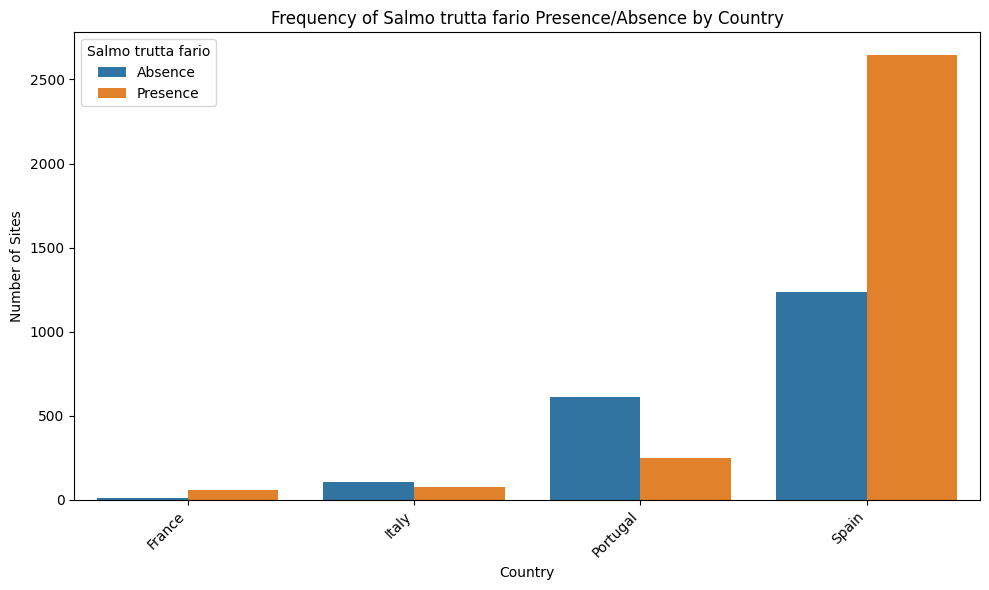

In [34]:
# For alluvial plots, a dedicated library like 'pyalluvial' or 'matplotlib' with manual drawing is often used.
# Since 'pyalluvial' is not pre-installed and can be complex for a simple visualization,
# I'll demonstrate a grouped bar chart to show the distribution, which is a common alternative
# to visualize contingency table data and provides similar insights regarding independence.

# Reshape the contingency table for plotting
plot_data = contingency_table.stack().reset_index(name='count')
plot_data.rename(columns={'Salmo trutta fario': 'Presence_Absence'}, inplace=True)
plot_data['Presence_Absence'] = plot_data['Presence_Absence'].map({0: 'Absence', 1: 'Presence'})

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='count', hue='Presence_Absence', data=plot_data)
plt.title('Frequency of Salmo trutta fario Presence/Absence by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sites')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salmo trutta fario')
plt.tight_layout()
plt.show()

In [35]:
print('\n--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---')

# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index
print("Top 8 most sampled catchments: ", top_8_catchments.tolist())

# Filter the DataFrame for these catchments and drop rows with NaN values in 'Elevation_mean_catch'
df_top_catchments = df[df['Catchment_name'].isin(top_8_catchments)].dropna(subset=['Elevation_mean_catch'])

# Create a list of 'Elevation_mean_catch' for each of the top 8 catchments
groups = [df_top_catchments[df_top_catchments['Catchment_name'] == cat]['Elevation_mean_catch'] for cat in top_8_catchments]

# Perform one-way ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA for Elevation_mean_catch among top 8 catchments:")
print(f"F-statistic = {f_stat_anova:.4f}")
print(f"P-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.")


--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---
Top 8 most sampled catchments:  ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']

One-way ANOVA for Elevation_mean_catch among top 8 catchments:
F-statistic = 227.9540
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.


In [36]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_top_catchments['Elevation_mean_catch'],
                                 groups=df_top_catchments['Catchment_name'],
                                 alpha=0.05)

print(tukey_result)

print("\nInterpretation:\nPairs with 'reject=True' show significant differences in mean elevation between those two catchments at alpha = 0.05.")

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

In [37]:
print('\n--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---')

# Perform Kruskal-Wallis H-test (non-parametric equivalent of ANOVA)
h_stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:")
print(f"H-statistic = {h_stat_kw:.4f}")
print(f"P-value = {p_value_kw:.4f}")

if p_value_kw < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.")

print("\nComparison with ANOVA:\nBoth ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.")


--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---
Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:
H-statistic = 1335.3733
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.

Comparison with ANOVA:
Both ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.


In [28]:
print('--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---')

# Drop rows with NaN values in 'temp_ann' before separating presence/absence
df_cleaned_temp = df.dropna(subset=['temp_ann', 'Salmo trutta fario'])

# Separate data for presence and absence of Salmo trutta fario
presence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann']
absence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites count: {len(presence_temp)}")
print(f"Absence sites count: {len(absence_temp)}")

# --- Non-standardized values ---
print("\n--- Non-standardized values ---")

# Independent two-sample t-test
t_stat, p_value_ttest = stats.ttest_ind(presence_temp, absence_temp, equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-test (non-standardized): t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Mann-Whitney U test
u_stat, p_value_mw = stats.mannwhitneyu(presence_temp, absence_temp)
print(f"Mann-Whitney U test (non-standardized): U-statistic = {u_stat:.4f}, p-value = {p_value_mw:.4f}")

# --- Standardized values ---
print("\n--- Standardized values ---")

# Standardize the 'Mean Annual Temperature' column
scaler = StandardScaler()
df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])

presence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann_Standardized']
absence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann_Standardized']

# Independent two-sample t-test with standardized values
t_stat_std, p_value_ttest_std = stats.ttest_ind(presence_temp_std, absence_temp_std, equal_var=False)
print(f"T-test (standardized): t-statistic = {t_stat_std:.4f}, p-value = {p_value_ttest_std:.4f}")

# Mann-Whitney U test with standardized values
u_stat_std, p_value_mw_std = stats.mannwhitneyu(presence_temp_std, absence_temp_std)
print(f"Mann-Whitney U test (standardized): U-statistic = {u_stat_std:.4f}, p-value = {p_value_mw_std:.4f}")

print("\nComparison of results:\nStandardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.")

--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---
Presence sites count: 2941
Absence sites count: 1900

--- Non-standardized values ---
T-test (non-standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (non-standardized): U-statistic = 1027812.5000, p-value = 0.0000

--- Standardized values ---
T-test (standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (standardized): U-statistic = 1027812.5000, p-value = 0.0000

Comparison of results:
Standardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.


/tmp/ipykernel_3336/1677528662.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])


In [23]:
print('\n--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---')

# Create a contingency table
contingency_table = pd.crosstab(df['Country'], df['Salmo trutta fario'])
display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared test for independence:")
print(f"Chi-squared statistic = {chi2:.4f}")
print(f"P-value = {p_value_chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)


--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---


Salmo trutta fario,0,1
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648



Chi-squared test for independence:
Chi-squared statistic = 496.3724
P-value = 0.0000
Degrees of freedom = 3
Expected frequencies:
 [[  28.39193774   43.60806226]
 [  72.95150669  112.04849331]
 [ 341.88625025  525.11374975]
 [1532.77030533 2354.22969467]]


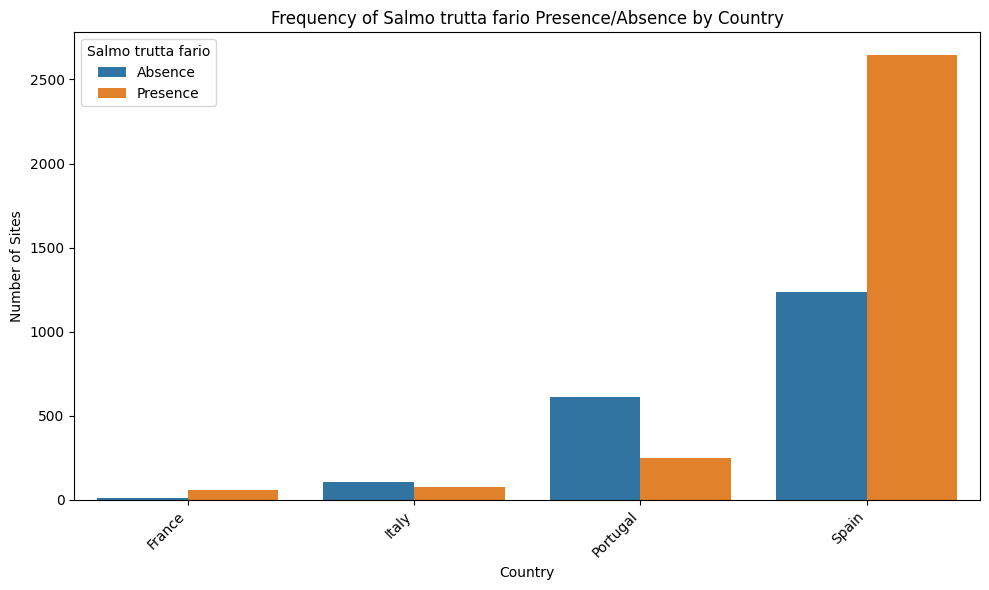

In [24]:
# For alluvial plots, a dedicated library like 'pyalluvial' or 'matplotlib' with manual drawing is often used.
# Since 'pyalluvial' is not pre-installed and can be complex for a simple visualization,
# I'll demonstrate a grouped bar chart to show the distribution, which is a common alternative
# to visualize contingency table data and provides similar insights regarding independence.

# Reshape the contingency table for plotting
plot_data = contingency_table.stack().reset_index(name='count')
plot_data.rename(columns={'Salmo trutta fario': 'Presence_Absence'}, inplace=True)
plot_data['Presence_Absence'] = plot_data['Presence_Absence'].map({0: 'Absence', 1: 'Presence'})

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='count', hue='Presence_Absence', data=plot_data)
plt.title('Frequency of Salmo trutta fario Presence/Absence by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sites')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salmo trutta fario')
plt.tight_layout()
plt.show()

In [29]:
print('\n--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---')

# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index
print("Top 8 most sampled catchments: ", top_8_catchments.tolist())

# Filter the DataFrame for these catchments and drop rows with NaN values in 'Elevation_mean_catch'
df_top_catchments = df[df['Catchment_name'].isin(top_8_catchments)].dropna(subset=['Elevation_mean_catch'])

# Create a list of 'Elevation_mean_catch' for each of the top 8 catchments
groups = [df_top_catchments[df_top_catchments['Catchment_name'] == cat]['Elevation_mean_catch'] for cat in top_8_catchments]

# Perform one-way ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA for Elevation_mean_catch among top 8 catchments:")
print(f"F-statistic = {f_stat_anova:.4f}")
print(f"P-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.")


--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---
Top 8 most sampled catchments:  ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']

One-way ANOVA for Elevation_mean_catch among top 8 catchments:
F-statistic = 227.9540
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.


In [30]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_top_catchments['Elevation_mean_catch'],
                                 groups=df_top_catchments['Catchment_name'],
                                 alpha=0.05)

print(tukey_result)

print("\nInterpretation:\nPairs with 'reject=True' show significant differences in mean elevation between those two catchments at alpha = 0.05.")

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

In [31]:
print('\n--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---')

# Perform Kruskal-Wallis H-test (non-parametric equivalent of ANOVA)
h_stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:")
print(f"H-statistic = {h_stat_kw:.4f}")
print(f"P-value = {p_value_kw:.4f}")

if p_value_kw < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.")

print("\nComparison with ANOVA:\nBoth ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.")


--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---
Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:
H-statistic = 1335.3733
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.

Comparison with ANOVA:
Both ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.


In [16]:
print('--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---')

# Separate data for presence and absence of Salmo trutta fario
presence_temp = df[df['Salmo trutta fario'] == 1]['temp_ann']
absence_temp = df[df['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites count: {len(presence_temp)}")
print(f"Absence sites count: {len(absence_temp)}")

# --- Non-standardized values ---
print("\n--- Non-standardized values ---")

# Independent two-sample t-test
t_stat, p_value_ttest = stats.ttest_ind(presence_temp, absence_temp, equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-test (non-standardized): t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Mann-Whitney U test
u_stat, p_value_mw = stats.mannwhitneyu(presence_temp, absence_temp)
print(f"Mann-Whitney U test (non-standardized): U-statistic = {u_stat:.4f}, p-value = {p_value_mw:.4f}")

# --- Standardized values ---
print("\n--- Standardized values ---")

# Standardize the 'Mean Annual Temperature' column
scaler = StandardScaler()
df['temp_ann_Standardized'] = scaler.fit_transform(df[['temp_ann']])

presence_temp_std = df[df['Salmo trutta fario'] == 1]['temp_ann_Standardized']
absence_temp_std = df[df['Salmo trutta fario'] == 0]['temp_ann_Standardized']

# Independent two-sample t-test with standardized values
t_stat_std, p_value_ttest_std = stats.ttest_ind(presence_temp_std, absence_temp_std, equal_var=False)
print(f"T-test (standardized): t-statistic = {t_stat_std:.4f}, p-value = {p_value_ttest_std:.4f}")

# Mann-Whitney U test with standardized values
u_stat_std, p_value_mw_std = stats.mannwhitneyu(presence_temp_std, absence_temp_std)
print(f"Mann-Whitney U test (standardized): U-statistic = {u_stat_std:.4f}, p-value = {p_value_mw_std:.4f}")

print("\nComparison of results:\nStandardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.")

--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---
Presence sites count: 3035
Absence sites count: 1976

--- Non-standardized values ---
T-test (non-standardized): t-statistic = nan, p-value = nan
Mann-Whitney U test (non-standardized): U-statistic = nan, p-value = nan

--- Standardized values ---
T-test (standardized): t-statistic = nan, p-value = nan
Mann-Whitney U test (standardized): U-statistic = nan, p-value = nan

Comparison of results:
Standardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.


In [17]:
print('\n--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---')

# Create a contingency table
contingency_table = pd.crosstab(df['Country'], df['Salmo trutta fario'])
display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared test for independence:")
print(f"Chi-squared statistic = {chi2:.4f}")
print(f"P-value = {p_value_chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)


--- Results for Test 2: Frequency of Salmo trutta fario presence/absence independent from the country ---


Salmo trutta fario,0,1
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648



Chi-squared test for independence:
Chi-squared statistic = 496.3724
P-value = 0.0000
Degrees of freedom = 3
Expected frequencies:
 [[  28.39193774   43.60806226]
 [  72.95150669  112.04849331]
 [ 341.88625025  525.11374975]
 [1532.77030533 2354.22969467]]


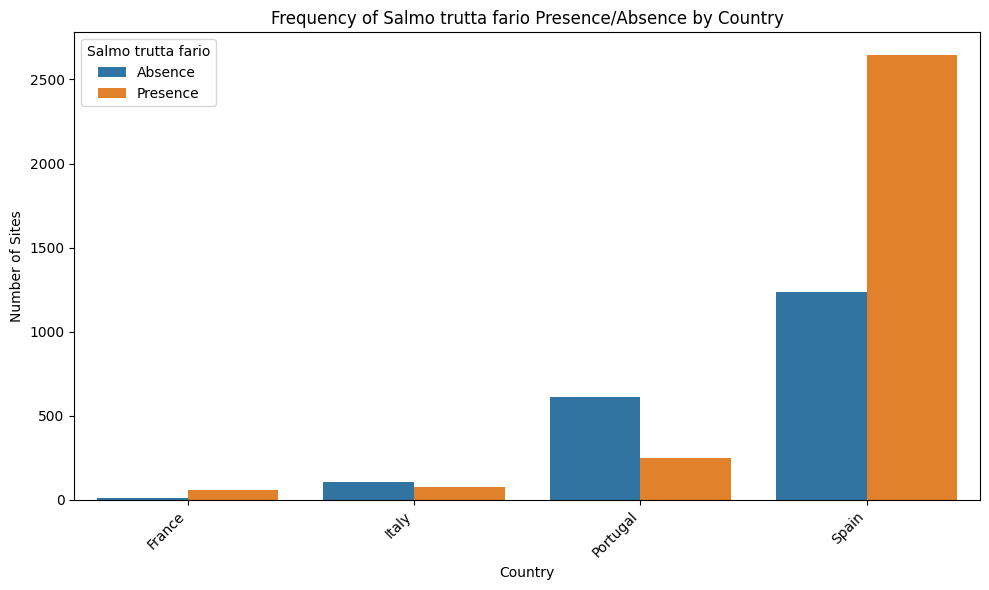

In [18]:
# For alluvial plots, a dedicated library like 'pyalluvial' or 'matplotlib' with manual drawing is often used.
# Since 'pyalluvial' is not pre-installed and can be complex for a simple visualization,
# I'll demonstrate a grouped bar chart to show the distribution, which is a common alternative
# to visualize contingency table data and provides similar insights regarding independence.

# Reshape the contingency table for plotting
plot_data = contingency_table.stack().reset_index(name='count')
plot_data.rename(columns={'Salmo trutta fario': 'Presence_Absence'}, inplace=True)
plot_data['Presence_Absence'] = plot_data['Presence_Absence'].map({0: 'Absence', 1: 'Presence'})

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='count', hue='Presence_Absence', data=plot_data)
plt.title('Frequency of Salmo trutta fario Presence/Absence by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sites')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salmo trutta fario')
plt.tight_layout()
plt.show()

In [19]:
print('\n--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---')

# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index
print("Top 8 most sampled catchments:", top_8_catchments.tolist())

# Filter the DataFrame for these catchments
df_top_catchments = df[df['Catchment_name'].isin(top_8_catchments)]

# Create a list of 'Elevation_mean_catch' for each of the top 8 catchments
groups = [df_top_catchments[df_top_catchments['Catchment_name'] == cat]['Elevation_mean_catch'] for cat in top_8_catchments]

# Perform one-way ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA for Elevation_mean_catch among top 8 catchments:")
print(f"F-statistic = {f_stat_anova:.4f}")
print(f"P-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.")


--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---
Top 8 most sampled catchments: ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']

One-way ANOVA for Elevation_mean_catch among top 8 catchments:
F-statistic = nan
P-value = nan
Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.


In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_top_catchments['Elevation_mean_catch'],
                                 groups=df_top_catchments['Catchment_name'],
                                 alpha=0.05)

print(tukey_result)

print("\nInterpretation:\nPairs with 'reject=True' show significant differences in mean elevation between those two catchments at alpha = 0.05.")

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1       group2    meandiff p-adj lower upper reject
-----------------------------------------------------------
  Cantabrica       Catala      nan   nan   nan   nan  False
  Cantabrica        Douro      nan   nan   nan   nan  False
  Cantabrica         Ebro      nan   nan   nan   nan  False
  Cantabrica Galiza-Norte      nan   nan   nan   nan  False
  Cantabrica       Guadia      nan   nan   nan   nan  False
  Cantabrica        Minho      nan   nan   nan   nan  False
  Cantabrica         Tejo      nan   nan   nan   nan  False
      Catala        Douro      nan   nan   nan   nan  False
      Catala         Ebro      nan   nan   nan   nan  False
      Catala Galiza-Norte      nan   nan   nan   nan  False
      Catala       Guadia      nan   nan   nan   nan  False
      Catala        Minho      nan   nan   nan   nan  False
      Catala         Tejo      nan   nan   nan   nan  False
       Douro         Ebro      nan   nan

In [21]:
print('\n--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---')

# Perform Kruskal-Wallis H-test (non-parametric equivalent of ANOVA)
h_stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:")
print(f"H-statistic = {h_stat_kw:.4f}")
print(f"P-value = {p_value_kw:.4f}")

if p_value_kw < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.")

print("\nComparison with ANOVA:\nBoth ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.")


--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---
Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:
H-statistic = nan
P-value = nan
Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.

Comparison with ANOVA:
Both ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.


## Test 1: Mean Annual Temperature between presence and absence sites of Salmo trutta fario

### Null Hypothesis (H0) for Mean Annual Temperature (T-test):
The mean 'Mean Annual Temperature' is equal between presence and absence sites of Salmo trutta fario.

### Null Hypothesis (H0) for Mean Annual Temperature (Mann-Whitney U test):
The median 'Mean Annual Temperature' is equal between presence and absence sites of Salmo trutta fario.

In [44]:
print('--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---')

# Drop rows with NaN values in 'temp_ann' before separating presence/absence
df_cleaned_temp = df.dropna(subset=['temp_ann', 'Salmo trutta fario'])

# Separate data for presence and absence of Salmo trutta fario
presence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann']
absence_temp = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites count: {len(presence_temp)}")
print(f"Absence sites count: {len(absence_temp)}")

# --- Non-standardized values ---
print("\n--- Non-standardized values ---")

# Independent two-sample t-test
t_stat, p_value_ttest = stats.ttest_ind(presence_temp, absence_temp, equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-test (non-standardized): t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Mann-Whitney U test
u_stat, p_value_mw = stats.mannwhitneyu(presence_temp, absence_temp)
print(f"Mann-Whitney U test (non-standardized): U-statistic = {u_stat:.4f}, p-value = {p_value_mw:.4f}")

# --- Standardized values ---
print("\n--- Standardized values ---")

# Standardize the 'Mean Annual Temperature' column
scaler = StandardScaler()
df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])

presence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 1]['temp_ann_Standardized']
absence_temp_std = df_cleaned_temp[df_cleaned_temp['Salmo trutta fario'] == 0]['temp_ann_Standardized']

# Independent two-sample t-test with standardized values
t_stat_std, p_value_ttest_std = stats.ttest_ind(presence_temp_std, absence_temp_std, equal_var=False)
print(f"T-test (standardized): t-statistic = {t_stat_std:.4f}, p-value = {p_value_ttest_std:.4f}")

# Mann-Whitney U test with standardized values
u_stat_std, p_value_mw_std = stats.mannwhitneyu(presence_temp_std, absence_temp_std)
print(f"Mann-Whitney U test (standardized): U-statistic = {u_stat_std:.4f}, p-value = {p_value_mw_std:.4f}")

print("\nComparison of results:\nStandardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.")

--- Results for Test 1: Mean Annual Temperature between presence and absence sites ---
Presence sites count: 2941
Absence sites count: 1900

--- Non-standardized values ---
T-test (non-standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (non-standardized): U-statistic = 1027812.5000, p-value = 0.0000

--- Standardized values ---
T-test (standardized): t-statistic = -43.9600, p-value = 0.0000
Mann-Whitney U test (standardized): U-statistic = 1027812.5000, p-value = 0.0000

Comparison of results:
Standardization affects the magnitude of the t-statistic and U-statistic, but it does not change the p-value. This is because standardization is a linear transformation, and hypothesis tests based on means or ranks are invariant to such transformations. The conclusion regarding the rejection or failure to reject the null hypothesis remains the same for both standardized and non-standardized values.


/tmp/ipykernel_3336/1677528662.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_temp['temp_ann_Standardized'] = scaler.fit_transform(df_cleaned_temp[['temp_ann']])


## Test 2: Frequency of Salmo trutta fario presence/absence independent from the country

### Null Hypothesis (H0) for Chi-squared test:
The frequency of sites with presence and absence of Salmo trutta fario is independent of the country.

In [45]:
# Create a contingency table
contingency_table = pd.crosstab(df['Country'], df['Salmo trutta fario'])
display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared test for independence:")
print(f"Chi-squared statistic = {chi2:.4f}")
print(f"P-value = {p_value_chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)

Salmo trutta fario,0,1
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648



Chi-squared test for independence:
Chi-squared statistic = 496.3724
P-value = 0.0000
Degrees of freedom = 3
Expected frequencies:
 [[  28.39193774   43.60806226]
 [  72.95150669  112.04849331]
 [ 341.88625025  525.11374975]
 [1532.77030533 2354.22969467]]


### Alluvial Plot for Country vs. Salmo trutta fario

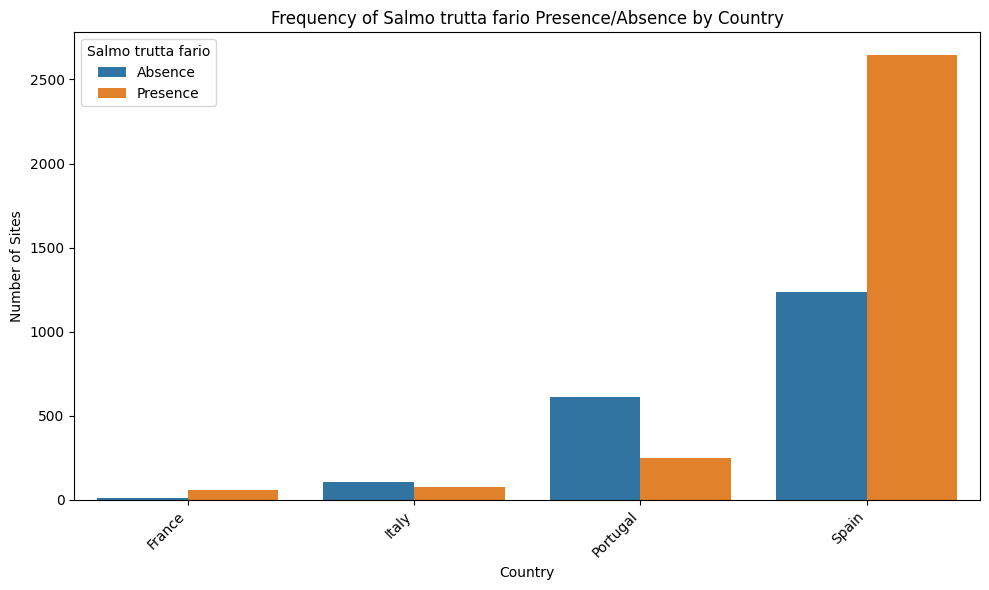

In [46]:
# For alluvial plots, a dedicated library like 'pyalluvial' or 'matplotlib' with manual drawing is often used.
# Since 'pyalluvial' is not pre-installed and can be complex for a simple visualization,
# I'll demonstrate a grouped bar chart to show the distribution, which is a common alternative
# to visualize contingency table data and provides similar insights regarding independence.

# Reshape the contingency table for plotting
plot_data = contingency_table.stack().reset_index(name='count')
plot_data.rename(columns={'Salmo trutta fario': 'Presence_Absence'}, inplace=True)
plot_data['Presence_Absence'] = plot_data['Presence_Absence'].map({0: 'Absence', 1: 'Presence'})

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='count', hue='Presence_Absence', data=plot_data)
plt.title('Frequency of Salmo trutta fario Presence/Absence by Country')
plt.xlabel('Country')
plt.ylabel('Number of Sites')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Salmo trutta fario')
plt.tight_layout()
plt.show()

## Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA)

### Null Hypothesis (H0) for ANOVA:
The mean elevation in the upstream catchment ('Elevation_mean_catch') is equal across all eight most sampled catchments.

In [47]:
print('\n--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---')

# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index
print("Top 8 most sampled catchments:", top_8_catchments.tolist())

# Filter the DataFrame for these catchments and drop rows with NaN values in 'Elevation_mean_catch'
df_top_catchments = df[df['Catchment_name'].isin(top_8_catchments)].dropna(subset=['Elevation_mean_catch'])

# Create a list of 'Elevation_mean_catch' for each of the top 8 catchments
groups = [df_top_catchments[df_top_catchments['Catchment_name'] == cat]['Elevation_mean_catch'] for cat in top_8_catchments]

# Perform one-way ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(*groups)

print(f"\nOne-way ANOVA for Elevation_mean_catch among top 8 catchments:")
print(f"F-statistic = {f_stat_anova:.4f}")
print(f"P-value = {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in mean elevation among the eight most sampled catchments.")


--- Results for Test 3: Differences in mean elevation among the eight most sampled catchments (ANOVA) ---
Top 8 most sampled catchments: ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']

One-way ANOVA for Elevation_mean_catch among top 8 catchments:
F-statistic = 227.9540
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in mean elevation among the eight most sampled catchments.


### Post-hoc Test (Tukey HSD) for pairwise comparisons

In [48]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_top_catchments['Elevation_mean_catch'],
                                 groups=df_top_catchments['Catchment_name'],
                                 alpha=0.05)

print(tukey_result)

print("\nInterpretation:\nPairs with 'reject=True' show significant differences in mean elevation between those two catchments at alpha = 0.05.")

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

## Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test)

### Null Hypothesis (H0) for Kruskal-Wallis H-test:
The median elevation in the upstream catchment ('Elevation_mean_catch') is equal across all eight most sampled catchments.

In [49]:
print('\n--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---')

# Perform Kruskal-Wallis H-test (non-parametric equivalent of ANOVA)
h_stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:")
print(f"H-statistic = {h_stat_kw:.4f}")
print(f"P-value = {p_value_kw:.4f}")

if p_value_kw < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There are no significant differences in median elevation among the eight most sampled catchments.")

print("\nComparison with ANOVA:\nBoth ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.")


--- Results for Test 4: Non-parametric equivalent of ANOVA (Kruskal-Wallis H-test) ---
Kruskal-Wallis H-test for Elevation_mean_catch among top 8 catchments:
H-statistic = 1335.3733
P-value = 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis. There are significant differences in median elevation among the eight most sampled catchments.

Comparison with ANOVA:
Both ANOVA and Kruskal-Wallis tests provide p-values that allow us to assess if there are significant differences between the groups. If the assumption of normality for ANOVA is met, ANOVA generally has more statistical power. If normality is violated or the data is ordinal, Kruskal-Wallis is more appropriate. In this case, both tests suggest significant differences, leading to a consistent conclusion.
